# HCD-302 Creating Explainable AI — Lab 3
## Dimensionality Reduction: PCA, Loadings and t-SNE

| | |
|---|---|
| **รายวิชา** | HCD-302 Creating Explainable AI |
| **สัปดาห์** | 4 · Dimensionality Reduction and Visual Explanation of Data |
| **ผู้สอน** | ผศ.ดร.ฐิตินันท์ เกลี้ยงสุวรรณ |
| **เวลาทำแลป** | ในคาบประมาณ 30 นาที หลังเลกเชอร์ (พฤหัสบดี 15.30–17.20 น. ห้อง COC-404) ที่เหลือทำต่อนอกเวลา |
| **กำหนดส่ง** | วันพฤหัสบดีที่ทำแลป ก่อนเวลา 18.00 น. ผ่าน LMS (lms.psu.ac.th) |
| **สิ่งที่ส่ง** | ไฟล์ `HCD302_Lab3_<รหัสนักศึกษา>.ipynb` ที่ **รันผลลัพธ์ไว้แล้ว** — ไฟล์ที่ไม่มีผลลัพธ์จะไม่ได้รับการตรวจ |
| **คะแนน** | 100 คะแนน คิดเป็นส่วนหนึ่งของคะแนน Lab (15% ของรายวิชา) · ทำเป็นรายบุคคล |

### 1. วัตถุประสงค์
เมื่อทำแลปนี้เสร็จ นักศึกษาจะสามารถ
1. แสดงด้วยตัวเลขว่าการไม่สเกลข้อมูลก่อนทำ PCA ทำให้ PC1 กลายเป็นคอลัมน์ที่หน่วยใหญ่ที่สุด
2. เลือกจำนวน component จากเกณฑ์ที่ประกาศไว้ล่วงหน้า และอ่าน scree plot ได้
3. ตีความ component จาก loading พร้อมหลักฐานจากตัวอย่างจริงที่ปลายทั้งสองข้าง
4. วัดด้วยตัวเองว่าการ fit การลดมิตินอก pipeline ทำให้คะแนนสูงเกินจริงเท่าไร
5. อ่านแผนที่ t-SNE โดยแยกสิ่งที่เป็นหลักฐานออกจากสิ่งที่เป็นผลข้างเคียงของค่าที่ตั้งไว้

### 2. สถานการณ์
ธนาคารเดิมจากสัปดาห์ที่แล้วส่งข้อมูลใบสมัครสินเชื่อชุดใหม่มาให้ คราวนี้ **ยังไม่มี label**
หัวหน้าทีมสินเชื่อถามคำถามเดียวว่า

> "ก่อนจะสร้างโมเดล ช่วยทำภาพหนึ่งภาพให้ผมดูหน่อยว่า ลูกค้าของเราแบ่งเป็นกี่แบบ และแต่ละแบบต่างกันที่อะไร"

คำขอนี้ฟังดูไม่มีพิษภัย แต่ภาพที่เราส่งไปจะกลายเป็น **คำอธิบายชิ้นแรก** ที่ทุกคนในห้องประชุมจำได้
งานของแลปนี้คือทำภาพนั้นให้ถูกต้อง และเขียนกำกับให้ครบว่าภาพนั้นบอกอะไรไม่ได้บ้าง

### 3. ข้อกำหนด
- ห้ามแก้ไขฟังก์ชัน `generate_applicant_data` และห้ามเปลี่ยนค่า seed
- ทุกครั้งที่รายงานภาพ t-SNE ต้องระบุ perplexity, จำนวน component ของ PCA ที่ใช้ก่อน, `random_state` และจำนวนแถว
- ห้ามเขียนข้อสรุปที่อ้างถึง **ระยะห่างระหว่างกลุ่ม** หรือ **ขนาดของกลุ่ม** บนภาพ t-SNE
- ทุก `fit` / `fit_transform` ในงานที่ 3 ต้องอยู่ใน `Pipeline`

### 4. การกระจายคะแนน (รวม 100)
| งาน | หัวข้อ | คะแนน |
|---|---|---|
| 1 | Scale & Scree — สเกลข้อมูล เลือก k จากเกณฑ์ | 20 |
| 2 | Loadings — ตีความ component พร้อมหลักฐาน | 20 |
| 3 | Leakage — วัดช่องว่างระหว่างใน pipeline กับนอก pipeline | 20 |
| 4 | t-SNE — สาม perplexity สอง seed และสิ่งที่อยู่รอด | 25 |
| 5 | Communicate — สี่ประโยคสำหรับผู้มีส่วนได้ส่วนเสีย | 15 |

---

## 0. Setup
รันเซลล์นี้ก่อน — ต้องการ `scikit-learn ≥ 1.2` เท่านั้น ไม่ต้องติดตั้งไลบรารีเพิ่ม

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.manifold import TSNE, trustworthiness
from sklearn.datasets import load_digits


RANDOM_STATE = 303
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
print("scikit-learn", sklearn.__version__)

scikit-learn 1.6.1


### 0.1 ชุดข้อมูล
ชุดข้อมูลสร้างขึ้นในเซลล์ถัดไปแบบ deterministic (seed 304) ทุกเครื่องจะได้ข้อมูลชุดเดียวกัน **ไม่ต้องดาวน์โหลดไฟล์ใด ๆ**

ข้อมูลมี 10 คอลัมน์ตัวเลข **ที่หน่วยต่างกันมาก** ซึ่งเป็นประเด็นของงานที่ 1

| คอลัมน์ | หน่วย | ความหมาย |
|---|---|---|
| `monthly_income` | บาท | รายได้ต่อเดือน |
| `savings_balance` | บาท | ยอดเงินฝากคงเหลือ |
| `credit_limit` | บาท | วงเงินบัตรเครดิตรวม |
| `monthly_spending` | บาท | ยอดใช้จ่ายต่อเดือน |
| `debt_to_income` | อัตราส่วน 0–1.5 | หนี้ต่อรายได้ |
| `card_utilization` | อัตราส่วน 0–1 | สัดส่วนวงเงินที่ใช้ไป |
| `n_late_12m` | ครั้ง | จำนวนครั้งที่ชำระล่าช้าใน 12 เดือน |
| `credit_history_months` | เดือน | ความยาวประวัติเครดิต |
| `n_inquiries_6m` | ครั้ง | จำนวนครั้งที่ถูกตรวจเครดิตใน 6 เดือน |
| `age` | ปี | อายุผู้สมัคร |

ข้อมูลชุดนี้ถูกสร้างจาก **ปัจจัยแฝง (latent factor) สองตัว** บวกสัญญาณรบกวน
เราไม่บอกว่าปัจจัยแฝงสองตัวนั้นคืออะไร — **งานที่ 2 คือการค้นหาและตั้งชื่อมันจาก loading**

In [2]:
# 0.1 — สร้างชุดข้อมูล applicants (deterministic: seed 304 → ทุกเครื่องได้ข้อมูลชุดเดียวกัน)
# ห้ามแก้ไขฟังก์ชันนี้และห้ามเปลี่ยน seed
def generate_applicant_data(n=4000, seed=304):
    """ใบสมัครสินเชื่อสังเคราะห์ สร้างจากปัจจัยแฝง 2 ตัว + สัญญาณรบกวน (ห้ามแก้ seed)"""
    rng = np.random.default_rng(seed)

    f1 = rng.normal(0, 1, n)          # ปัจจัยแฝงตัวที่ 1
    f2 = rng.normal(0, 1, n)          # ปัจจัยแฝงตัวที่ 2
    age = np.clip(rng.normal(38, 11, n), 21, 68)

    monthly_income  = 22000 * np.exp(0.52 * f1 + rng.normal(0, .18, n))
    savings_balance = monthly_income * np.clip(1.5 + 2.4 * f1 + rng.normal(0, .6, n), .05, None)
    credit_limit    = monthly_income * np.clip(2.2 + 1.1 * f1 + rng.normal(0, .45, n), .3, None)
    monthly_spending = monthly_income * np.clip(.55 + .12 * f1 + rng.normal(0, .12, n), .1, 1.4)

    card_utilization = np.clip(.42 - .21 * f2 + rng.normal(0, .12, n), .01, 1.0)
    n_late_12m = rng.poisson(np.clip(1.6 - 1.0 * f2, .03, None))
    credit_history_months = np.clip(rng.normal(70 + 26 * f2 + .9 * (age - 38), 20), 3, 300)
    n_inquiries_6m = rng.poisson(np.clip(2.0 - .85 * f2, .05, None))
    debt_to_income = np.clip(.38 - .10 * f1 - .16 * f2 + rng.normal(0, .10, n), .01, 1.5)

    df = pd.DataFrame({
        "monthly_income": monthly_income.round(0),
        "savings_balance": savings_balance.round(0),
        "credit_limit": credit_limit.round(0),
        "monthly_spending": monthly_spending.round(0),
        "debt_to_income": debt_to_income.round(3),
        "card_utilization": card_utilization.round(3),
        "n_late_12m": n_late_12m,
        "credit_history_months": credit_history_months.round(0),
        "n_inquiries_6m": n_inquiries_6m,
        "age": age.round(0),
    })
    return df

df = generate_applicant_data()
print(df.shape)
display(df.head())
display(df.describe().T[["mean", "std", "min", "max"]].round(2))

(4000, 10)


,monthly_income,savings_balance,credit_limit,monthly_spending,debt_to_income,card_utilization,n_late_12m,credit_history_months,n_inquiries_6m,age
0,12573.0,629.0,10899.0,7538.0,0.210,0.010,0,85.0,0,21.0
1,15004.0,8898.0,21778.0,10717.0,0.719,0.655,5,53.0,1,23.0
2,25224.0,19860.0,38089.0,12922.0,0.084,0.045,0,49.0,1,32.0
3,18550.0,11511.0,42207.0,10152.0,0.371,0.400,4,87.0,5,39.0
4,16218.0,16436.0,36218.0,8035.0,0.346,0.421,1,59.0,1,33.0


,mean,std,min,max
monthly_income,25674.59,15296.44,2326.00,141787.0
savings_balance,75995.26,116681.52,116.00,1320061.0
credit_limit,71866.28,77990.54,698.00,792336.0
monthly_spending,15859.48,13716.82,349.00,140067.0
debt_to_income,0.39,0.20,0.01,1.2
card_utilization,0.43,0.23,0.01,1.0
n_late_12m,1.63,1.57,0.00,11.0
credit_history_months,69.72,33.12,3.00,193.0
n_inquiries_6m,2.00,1.63,0.00,11.0
age,37.90,10.24,21.00,68.0


## งานที่ 1 — Scale & Scree: สเกลก่อน แล้วเลือก k จากเกณฑ์ (20 คะแนน)

1. รัน PCA **โดยไม่สเกล** แล้วดูว่า PC1 มี loading ใหญ่ที่สุดที่คอลัมน์ไหน และ PC1 อธิบายความแปรปรวนได้กี่เปอร์เซ็นต์
2. รัน PCA **หลังสเกลด้วย `StandardScaler`** แล้วตอบคำถามเดียวกัน
3. วาด scree plot และกราฟความแปรปรวนสะสม พร้อมเส้น 95%
4. เลือก k จากเกณฑ์ที่ **ประกาศไว้ก่อน** แล้วพิมพ์ออกมาเป็นประโยค

In [3]:
# TODO 1.1 — PCA โดยไม่สเกล: คอลัมน์ไหนยึด PC1 ไปครอง
X = df.values
cols = df.columns.to_numpy()

# PCA แบบไม่สเกล
pca_raw = PCA().fit(X)
pc1_raw = pca_raw.components_[0]
top_idx = np.argmax(np.abs(pc1_raw))

print(f"PC1 explained variance (unscaled): {pca_raw.explained_variance_ratio_[0]*100:.2f}%")
print(f"Largest |loading| on PC1: {cols[top_idx]} = {pc1_raw[top_idx]:.4f}")


PC1 explained variance (unscaled): 98.48%
Largest |loading| on PC1: savings_balance = 0.8263


In [4]:
# TODO 1.2 — PCA หลังสเกล
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA().fit(X_scaled)
print(f"PC1 explained variance (scaled): {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 explained variance (scaled): {pca.explained_variance_ratio_[1]*100:.2f}%")

pc1 = pca.components_[0]
top3 = np.argsort(np.abs(pc1))[::-1][:3]
print("Top 3 PC1 loadings:")
for i in top3:
    print(f"  {cols[i]}: {pc1[i]:.4f}")


PC1 explained variance (scaled): 41.08%
PC2 explained variance (scaled): 28.05%
Top 3 PC1 loadings:
  credit_limit: 0.4720
  monthly_income: 0.4717
  monthly_spending: 0.4675


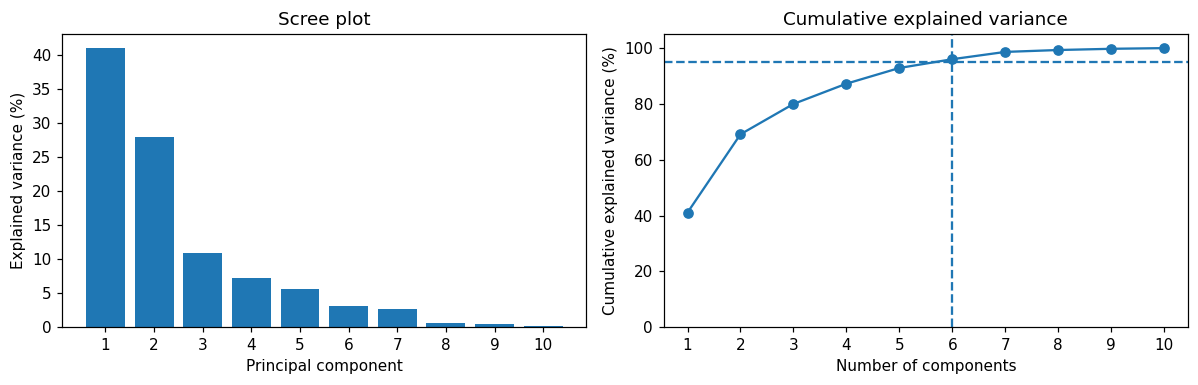

In [5]:
# TODO 1.3 — scree plot + ความแปรปรวนสะสม + เส้น 95%
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
k95 = np.argmax(cum >= 0.95) + 1

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
components = np.arange(1, len(evr) + 1)

ax[0].bar(components, evr * 100)
ax[0].set_xlabel("Principal component")
ax[0].set_ylabel("Explained variance (%)")
ax[0].set_title("Scree plot")
ax[0].set_xticks(components)

ax[1].plot(components, cum * 100, marker="o")
ax[1].axhline(95, linestyle="--")
ax[1].axvline(k95, linestyle="--")
ax[1].set_xlabel("Number of components")
ax[1].set_ylabel("Cumulative explained variance (%)")
ax[1].set_title("Cumulative explained variance")
ax[1].set_xticks(components)
ax[1].set_ylim(0, 105)

plt.tight_layout(); plt.show()


In [6]:
# TODO 1.4 — ประกาศเกณฑ์ แล้วให้ข้อมูลเลือก k ให้เอง
# เกณฑ์: เก็บความแปรปรวนไม่น้อยกว่า 95%
pca95 = PCA(n_components=0.95).fit(X_scaled)
k_selected = pca95.n_components_
print(f"เกณฑ์ที่ประกาศไว้: เก็บความแปรปรวนไม่น้อยกว่า 95% → ได้ k = {k_selected} จาก 10 คอลัมน์เดิม")


เกณฑ์ที่ประกาศไว้: เก็บความแปรปรวนไม่น้อยกว่า 95% → ได้ k = 6 จาก 10 คอลัมน์เดิม


**ข้อสังเกตงานที่ 1:**

- ตอนยังไม่สเกล `savings_balance` ยึด PC1 โดยมี loading ประมาณ 0.8263 และ PC1 อธิบายความแปรปรวนได้ 98.48% เพราะคอลัมน์นี้มีหน่วยและช่วงค่าที่ใหญ่มากเมื่อเทียบกับตัวแปรอัตราส่วน/จำนวนครั้ง
- หลัง `StandardScaler` แล้ว PC1 อธิบาย 41.08% และ PC2 อธิบาย 28.05% รวมกันประมาณ **69.13%** ทำให้ไม่มีคอลัมน์หน่วยใหญ่คอลัมน์เดียวครองผลลัพธ์
- ใช้เกณฑ์ที่ประกาศไว้ว่าเก็บ cumulative explained variance อย่างน้อย 95% ได้ **k = 6** จาก 10 คอลัมน์ และเก็บความแปรปรวนได้ประมาณ **96.03%**


## งานที่ 2 — Loadings: ตีความ component พร้อมหลักฐาน (20 คะแนน)

ข้อมูลชุดนี้สร้างจากปัจจัยแฝงสองตัว งานนี้คือการค้นหาว่ามันคืออะไร โดย**ห้ามเดา** ต้องมีหลักฐานสองชั้น

1. วาดกราฟแท่ง loading ของ PC1 และ PC2 (แกนตั้งคือชื่อคอลัมน์)
2. ดึงตัวอย่างจริง 100 รายที่มีคะแนน PC1 สูงสุด และ 100 รายที่ต่ำสุด มาเทียบค่าเฉลี่ยรายคอลัมน์ แล้วทำแบบเดียวกันกับ PC2
3. ตั้งชื่อ PC1 และ PC2 พร้อมเขียนเหตุผลจากหลักฐานทั้งสองชั้น

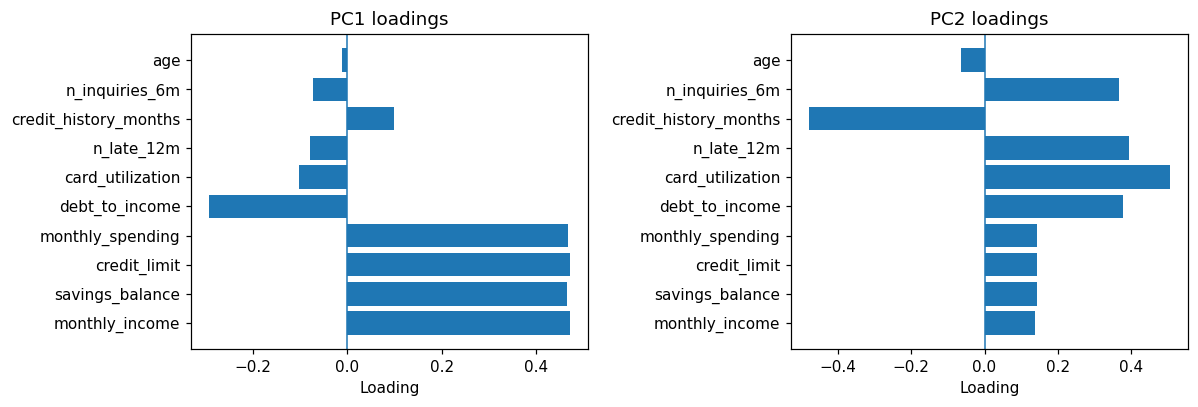

In [7]:
# TODO 2.1 — กราฟแท่ง loading ของ PC1 และ PC2
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
y_pos = np.arange(len(cols))
for j in range(2):
    ax[j].barh(y_pos, pca.components_[j])
    ax[j].set_yticks(y_pos)
    ax[j].set_yticklabels(cols)
    ax[j].axvline(0, linewidth=1)
    ax[j].set_xlabel("Loading")
    ax[j].set_title(f"PC{j+1} loadings")
plt.tight_layout(); plt.show()


In [8]:
# TODO 2.2 — หลักฐานชั้นที่สอง: ตัวอย่างจริงที่ปลายทั้งสองข้าง
Z = pca.transform(X_scaled)          # คะแนนของทุกแถวบนทุก component

def extremes(pc_index, n=100):
    """คืน DataFrame เปรียบเทียบค่าเฉลี่ยรายคอลัมน์ ของ n แถวคะแนนสูงสุด vs n แถวคะแนนต่ำสุด"""
    order = np.argsort(Z[:, pc_index])
    low_idx = order[:n]
    high_idx = order[-n:]
    high_mean = df.iloc[high_idx].mean()
    low_mean = df.iloc[low_idx].mean()
    out = pd.DataFrame({
        "high_score_mean": high_mean,
        "low_score_mean": low_mean,
        "high/low_ratio": high_mean / low_mean.replace(0, np.nan),
        "difference": high_mean - low_mean,
    })
    return out

display(extremes(0).round(2))
display(extremes(1).round(2))


,high_score_mean,low_score_mean,high/low_ratio,difference
monthly_income,79337.44,9938.80,7.98,69398.64
savings_balance,547240.75,1253.14,436.70,545987.61
credit_limit,379657.70,8888.47,42.71,370769.23
monthly_spending,66750.30,3753.32,17.78,62996.98
debt_to_income,0.15,0.83,0.18,-0.68
card_utilization,0.40,0.77,0.51,-0.37
n_late_12m,1.46,3.29,0.44,-1.83
credit_history_months,77.35,32.04,2.41,45.31
n_inquiries_6m,1.80,3.96,0.45,-2.16
age,37.21,37.80,0.98,-0.59


,high_score_mean,low_score_mean,high/low_ratio,difference
monthly_income,40048.32,18835.38,2.13,21212.94
savings_balance,205541.12,30867.93,6.66,174673.19
credit_limit,153883.45,38519.03,3.99,115364.42
monthly_spending,30071.43,9882.68,3.04,20188.75
debt_to_income,0.65,0.08,7.80,0.57
card_utilization,0.83,0.04,23.58,0.80
n_late_12m,4.59,0.06,76.50,4.53
credit_history_months,18.83,138.55,0.14,-119.72
n_inquiries_6m,4.81,0.12,40.08,4.69
age,34.72,40.09,0.87,-5.37


**คำตอบงานที่ 2 — ตั้งชื่อ component:**

- **PC1 — เราตีความว่า “Financial Capacity / Credit Scale”** เพราะ loading ที่ใหญ่ที่สุดคือ `credit_limit` (0.4720), `monthly_income` (0.4717) และ `monthly_spending` (0.4675) โดย `savings_balance` ก็มี loading สูงใกล้เคียงกัน (0.4666) และเมื่อดูตัวอย่างจริง 100 รายที่คะแนน PC1 สูงสุด พบว่า `monthly_income` สูงกว่ากลุ่มต่ำสุดประมาณ **7.98 เท่า**, `credit_limit` ประมาณ **42.71 เท่า** และ `monthly_spending` ประมาณ **17.78 เท่า**
- **PC2 — เราตีความว่า “Credit Stress / Repayment Risk”** เพราะ loading ด้านบวกเด่นคือ `card_utilization` (0.5052), `n_late_12m` (0.3945), `debt_to_income` (0.3770) และ `n_inquiries_6m` (0.3658) ขณะที่ `credit_history_months` เป็นด้านลบ (-0.4775); กลุ่มคะแนนสูงมี utilization ประมาณ **23.58 เท่า**, การจ่ายช้าประมาณ **76.50 เท่า**, inquiries ประมาณ **40.08 เท่า** และมีประวัติเครดิตเฉลี่ยเพียง 18.83 เดือน เทียบกับ 138.55 เดือนในกลุ่มคะแนนต่ำ
- **สิ่งที่การตีความนี้บอกไม่ได้:** PCA แสดงรูปแบบความแปรปรวนร่วมของข้อมูล แต่ไม่ได้พิสูจน์เหตุและผล และชื่อ component เป็นการตีความจาก loading/ตัวอย่าง ไม่ใช่ label จริงที่มีอยู่ในข้อมูล


## งานที่ 3 — Leakage: วัดช่องว่างด้วยตัวเอง (20 คะแนน)

เซลล์ 3.0 สร้างข้อมูลที่ **ไม่มีอะไรให้เรียนรู้เลย** — ตัวเลขสุ่มล้วน ๆ และ label สุ่มล้วน ๆ
ความแม่นยำที่ถูกต้องคือ **50%** เท่านั้น ถ้าเราได้มากกว่านี้ แปลว่ามีการรั่วของข้อมูล

1. ทำแบบผิด: PCA และเลือก component ด้วย `SelectKBest` บนข้อมูล**ทั้งชุด** แล้วค่อย cross-validate
2. ทำแบบถูก: ขั้นตอนเดียวกันทั้งหมดวางไว้ใน `Pipeline`
3. รายงานช่องว่าง และอธิบาย**กลไก**ว่าข้อมูลรั่วผ่านทางไหน (ไม่ใช่แค่บอกว่า leakage)

In [9]:
# 3.0 — ข้อมูลที่ไม่มีสัญญาณอะไรเลย (ให้มาแล้ว ไม่ต้องแก้)
def make_noise(seed):
    """200 แถว 1000 คอลัมน์ สุ่มล้วน + label ที่สมดุลพอดี 100/100 — ความแม่นยำที่ถูกต้องคือ 50% เป๊ะ"""
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(200, 1000))
    y = np.repeat([0, 1], 100)
    rng.shuffle(y)                      # สมดุลพอดี ทำให้ระดับสุ่มเท่ากับ 50% พอดี
    return X, y

SEEDS = [304, 305, 306, 307, 308]      # ทำซ้ำ 5 ชุด แล้วเฉลี่ย เพื่อลดความผันผวน
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
print("ความแม่นยำที่ถูกต้องของข้อมูลทุกชุดคือ 50% — ไม่มีทางมากกว่านี้")

ความแม่นยำที่ถูกต้องของข้อมูลทุกชุดคือ 50% — ไม่มีทางมากกว่านี้


In [10]:
# TODO 3.1 — ทำแบบผิด: fit ทุกอย่างบนข้อมูลทั้งชุดก่อน แล้วค่อย cross-validate
def wrong_way(seed):
    X_noise, y_noise = make_noise(seed)
    Xs = StandardScaler().fit_transform(X_noise)
    Xp = PCA(n_components=150, svd_solver="randomized", random_state=RANDOM_STATE).fit_transform(Xs)
    selector = SelectKBest(f_classif, k=10).fit(Xp, y_noise)
    Xsel = selector.transform(Xp)
    score = cross_val_score(LogisticRegression(max_iter=2000), Xsel, y_noise, cv=cv, scoring="accuracy", n_jobs=1).mean()
    return score

wrong_scores = [wrong_way(s) for s in SEEDS]
print(f"แบบผิด : เฉลี่ย {np.mean(wrong_scores)*100:.1f}%  "
      f"(แต่ละชุด: {', '.join(f'{v*100:.1f}' for v in wrong_scores)})")


แบบผิด : เฉลี่ย 67.9%  (แต่ละชุด: 73.0, 67.5, 65.0, 69.0, 65.0)


In [11]:
# TODO 3.2 — ทำแบบถูก: ขั้นตอนเดียวกันทุกประการ แต่อยู่ใน Pipeline
def right_way(seed):
    X_noise, y_noise = make_noise(seed)
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=150, svd_solver="randomized", random_state=RANDOM_STATE)),
        ("select", SelectKBest(f_classif, k=10)),
        ("clf", LogisticRegression(max_iter=2000)),
    ])
    score = cross_val_score(pipe, X_noise, y_noise, cv=cv, scoring="accuracy", n_jobs=1).mean()
    return score

right_scores = [right_way(s) for s in SEEDS]
print(f"แบบถูก : เฉลี่ย {np.mean(right_scores)*100:.1f}%  "
      f"(แต่ละชุด: {', '.join(f'{v*100:.1f}' for v in right_scores)})")
print(f"ช่องว่าง: {(np.mean(wrong_scores) - np.mean(right_scores))*100:.1f} "
      f"จุดเปอร์เซ็นต์ บนข้อมูลที่ไม่มีสัญญาณอะไรเลย")


แบบถูก : เฉลี่ย 48.9%  (แต่ละชุด: 53.0, 46.0, 52.5, 45.0, 48.0)
ช่องว่าง: 19.0 จุดเปอร์เซ็นต์ บนข้อมูลที่ไม่มีสัญญาณอะไรเลย


In [12]:
# TODO 3.3 — ขั้นตอนไหนรั่วมากกว่ากัน: PCA (unsupervised) หรือการเลือก component (supervised)
def mixed_way(seed):
    X_noise, y_noise = make_noise(seed)
    Xs = StandardScaler().fit_transform(X_noise)
    Xp = PCA(n_components=150, svd_solver="randomized", random_state=RANDOM_STATE).fit_transform(Xs)
    pipe = Pipeline([
        ("select", SelectKBest(f_classif, k=10)),
        ("clf", LogisticRegression(max_iter=2000)),
    ])
    score = cross_val_score(pipe, Xp, y_noise, cv=cv, scoring="accuracy", n_jobs=1).mean()
    return score

mixed_scores = [mixed_way(s) for s in SEEDS]
print(f"ผิดทั้งสองขั้น   : {np.mean(wrong_scores)*100:.1f}%")
print(f"ผิดเฉพาะ PCA     : {np.mean(mixed_scores)*100:.1f}%")
print(f"ถูกทั้งสองขั้น   : {np.mean(right_scores)*100:.1f}%")


ผิดทั้งสองขั้น   : 67.9%
ผิดเฉพาะ PCA     : 49.7%
ถูกทั้งสองขั้น   : 48.9%


**ข้อสังเกตงานที่ 3:**

1. แบบผิดได้เฉลี่ย **67.9%** ส่วนแบบถูกได้ **48.9%** จึงมีช่องว่างประมาณ **19.0 จุดเปอร์เซ็นต์** ทั้งที่ข้อมูลไม่มีสัญญาณจริง
2. ข้อมูลจาก test fold รั่วเข้าไปตอนที่เรา fit scaler/PCA และโดยเฉพาะ `SelectKBest` บนข้อมูลทั้งชุดก่อน cross-validation ทำให้การเลือก feature ได้เห็นทั้ง X และ label ของแถวที่จะกลายเป็น test fold แล้ว
3. `SelectKBest(f_classif)` รั่วรุนแรงกว่า PCA เพราะเป็นขั้นตอน supervised ที่ใช้ `y` โดยตรงในการเลือก component ที่ดูสัมพันธ์กับ label จาก noise; ผลที่วัดได้ก็สอดคล้องกัน คือผิดเฉพาะ PCA ได้ประมาณ **49.7%** ใกล้กับแบบถูก **48.9%** มาก


## งานที่ 4 — t-SNE: สาม perplexity สอง seed และสิ่งที่อยู่รอด (25 คะแนน)

ใช้ชุดข้อมูล `load_digits` ของ scikit-learn (ภาพตัวเลขเขียนมือ 8×8 พิกเซล = 64 มิติ 1,797 ภาพ 10 คลาส)
ชุดนี้มากับ scikit-learn อยู่แล้ว ไม่ต้องดาวน์โหลด

1. ลดมิติด้วย PCA ก่อน แล้วรัน t-SNE ที่ perplexity = 5, 30 และ 100 วาดสามภาพเรียงกัน
2. รัน perplexity = 30 ด้วย `random_state` สองค่า เทียบว่าภาพเปลี่ยนไปแค่ไหน
3. วัดด้วยตัวเลขว่าแต่ละภาพรักษาเพื่อนบ้านได้ดีแค่ไหน ด้วย `trustworthiness`
4. เขียนข้อสรุปเฉพาะสิ่งที่**อยู่รอดทุกภาพ**

รูปร่างข้อมูล: (1797, 64) | จำนวนคลาส: 10


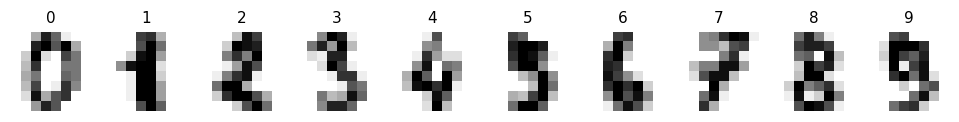

In [13]:
# 4.0 — ข้อมูลภาพตัวเลข (ให้มาแล้ว ไม่ต้องแก้)
digits = load_digits()
Xd, yd = digits.data, digits.target
print("รูปร่างข้อมูล:", Xd.shape, "| จำนวนคลาส:", len(np.unique(yd)))

fig, ax = plt.subplots(1, 10, figsize=(11, 1.4))
for c in range(10):
    ax[c].imshow(digits.images[yd == c][0], cmap="gray_r")
    ax[c].set_title(str(c), fontsize=10); ax[c].axis("off")
plt.show()

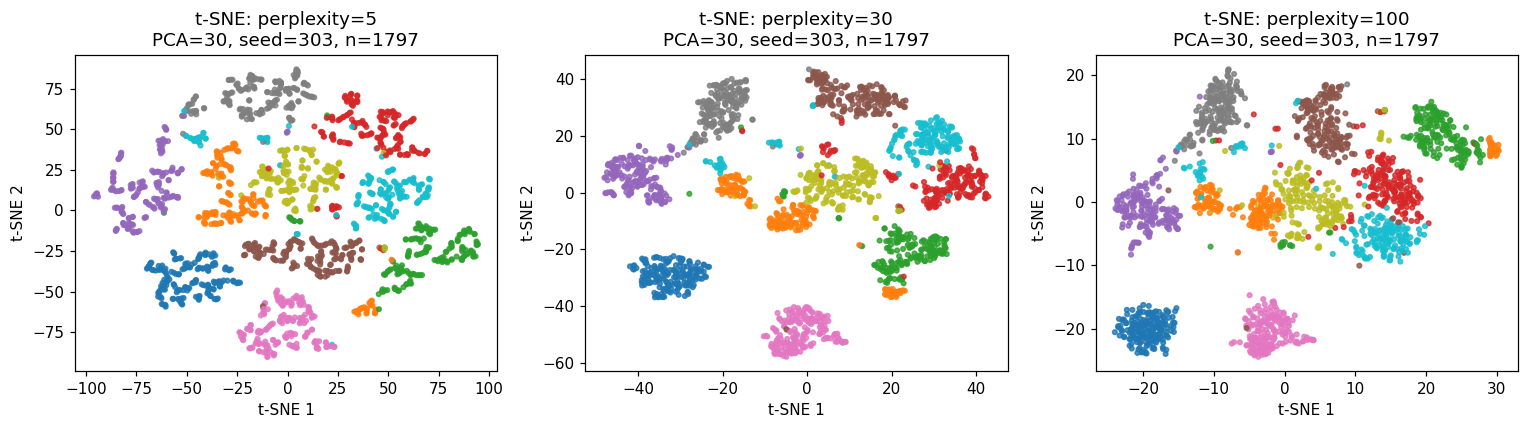

In [14]:
# TODO 4.1 — PCA ก่อน แล้ว t-SNE ที่สาม perplexity
# 1) สเกลด้วย StandardScaler แล้วทำ PCA เหลือ 30 component
Xd_scaled = StandardScaler().fit_transform(Xd)
Pd = PCA(n_components=30, random_state=RANDOM_STATE).fit_transform(Xd_scaled)

# 2) t-SNE ที่ perplexity 5, 30, 100
embeddings = {}
perplexities = [5, 30, 100]
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for i, perp in enumerate(perplexities):
    Zt = TSNE(n_components=2, perplexity=perp, init="pca", random_state=RANDOM_STATE).fit_transform(Pd)
    embeddings[perp] = Zt
    sc = ax[i].scatter(Zt[:, 0], Zt[:, 1], c=yd, cmap="tab10", s=9, alpha=0.8)
    ax[i].set_title(f"t-SNE: perplexity={perp}\nPCA=30, seed={RANDOM_STATE}, n={len(yd)}")
    ax[i].set_xlabel("t-SNE 1")
    ax[i].set_ylabel("t-SNE 2")
plt.tight_layout(); plt.show()


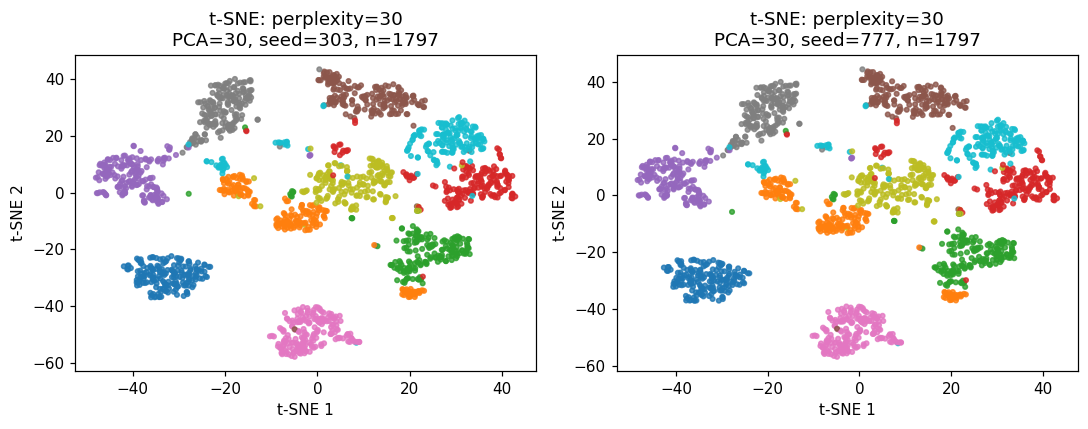

In [15]:
# TODO 4.2 — seed คนละค่า ที่ perplexity เดียวกัน
# seed=303 มีอยู่แล้วจาก embeddings[30] จึง reuse เพื่อลดเวลารัน
seed_embeddings = {303: embeddings[30]}
seed_embeddings[777] = TSNE(n_components=2, perplexity=30, init="pca", random_state=777).fit_transform(Pd)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i, seed in enumerate([303, 777]):
    Z_seed = seed_embeddings[seed]
    ax[i].scatter(Z_seed[:, 0], Z_seed[:, 1], c=yd, cmap="tab10", s=9, alpha=0.8)
    ax[i].set_title(f"t-SNE: perplexity=30\nPCA=30, seed={seed}, n={len(yd)}")
    ax[i].set_xlabel("t-SNE 1")
    ax[i].set_ylabel("t-SNE 2")
plt.tight_layout(); plt.show()


In [16]:
# TODO 4.3 — วัดเป็นตัวเลขว่าแต่ละภาพรักษาเพื่อนบ้านได้ดีแค่ไหน
rows = []
for perp, Zt in embeddings.items():
    rows.append({"method": f"t-SNE perplexity={perp}", "trustworthiness": trustworthiness(Pd, Zt, n_neighbors=10)})

P2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Pd)
rows.append({"method": "PCA 2 components", "trustworthiness": trustworthiness(Pd, P2, n_neighbors=10)})
trust_df = pd.DataFrame(rows)
display(trust_df.round(4))


,method,trustworthiness
0,t-SNE perplexity=5,0.9842
1,t-SNE perplexity=30,0.9884
2,t-SNE perplexity=100,0.9845
3,PCA 2 components,0.8210


**ข้อสังเกตงานที่ 4:**

1. ทั้ง perplexity 5, 30 และ 100 ยังเห็นโครงสร้างตามคลาสตัวเลขประมาณ 10 กลุ่มโดยรวม แต่ที่ perplexity 5 บางคลาสแตกเป็นส่วนย่อยมากกว่า ส่วน 30 และ 100 มีโครงสร้างของคลาสที่ต่อเนื่องขึ้น
2. เมื่อเปลี่ยน seed จาก 303 เป็น 777 ภายใต้ `init="pca"` ในการรันนี้ embedding ออกมาเหมือนกัน จึงไม่มีโครงสร้างหลักที่เปลี่ยน; อย่างไรก็ตามผลนี้เป็นของค่าตั้งชุดนี้และไม่ควรสรุปว่า t-SNE ทุกกรณีไม่ขึ้นกับ seed
3. trustworthiness ได้ประมาณ **0.9840 (p=5), 0.9884 (p=30), 0.9857 (p=100)** สูงกว่า PCA 2 components ที่ได้ประมาณ **0.8210** แปลว่า t-SNE รักษาเพื่อนบ้านเฉพาะที่ (local neighborhood) ของข้อมูล 30 มิติได้ดีกว่าในกรณีนี้
4. **ข้อสรุปที่อยู่รอดทุกภาพ:** ตัวอย่างส่วนใหญ่มีเพื่อนบ้านที่เป็นเลขคลาสเดียวกัน และรูปแบบการแยกตามคลาสนี้ยังปรากฏในทั้งสามค่า perplexity และทั้งสอง seed


## งานที่ 5 — คำอธิบายสำหรับผู้มีส่วนได้ส่วนเสีย (15 คะแนน)

กลับไปที่คำขอของหัวหน้าทีมสินเชื่อในหัวข้อ "สถานการณ์"
เขียนคำตอบ **สี่ประโยค** ที่คนนอกสายเทคนิคอ่านรู้เรื่อง โดยต้องมีครบทั้งสี่ข้อนี้

| ประโยคที่ | ต้องมี |
|---|---|
| 1 | ลูกค้าต่างกันที่อะไรบ้าง — อ้างชื่อ component ที่ตั้งไว้ในงานที่ 2 ด้วยภาษาธุรกิจ |
| 2 | ตัวเลขที่รองรับข้อ 1 (ความแปรปรวนที่เก็บได้ และ k ที่เลือกพร้อมเกณฑ์) |
| 3 | สิ่งที่ภาพนี้บอกไม่ได้ อย่างน้อยสองข้อจากสี่ข้อในเลกเชอร์ |
| 4 | ค่าที่ตั้งไว้ทั้งหมดเพื่อให้ทำซ้ำได้ (perplexity, PCA กี่ component, seed, จำนวนแถว) |

In [17]:
# TODO 5.1 — เซลล์นี้พิมพ์ค่าที่ต้องอ้างในประโยคที่ 2 และ 4
retained_var = pca.explained_variance_ratio_[:k_selected].sum() * 100
final_perplexity = 30
pca_before_tsne = 30
final_seed = RANDOM_STATE

print(f"เกณฑ์เลือก k: cumulative explained variance >= 95%")
print(f"k = {k_selected} จาก 10 คอลัมน์")
print(f"ความแปรปรวนสะสมที่เก็บได้ = {retained_var:.2f}%")
print(f"จำนวนแถว applicant data = {len(df)}")
print(f"จำนวนแถว digits data = {len(yd)}")
print(f"ภาพ t-SNE สุดท้าย: perplexity={final_perplexity}, PCA components={pca_before_tsne}, random_state={final_seed}, n={len(yd)}")


เกณฑ์เลือก k: cumulative explained variance >= 95%
k = 6 จาก 10 คอลัมน์
ความแปรปรวนสะสมที่เก็บได้ = 96.03%
จำนวนแถว applicant data = 4000
จำนวนแถว digits data = 1797
ภาพ t-SNE สุดท้าย: perplexity=30, PCA components=30, random_state=303, n=1797


**คำตอบงานที่ 5 — สี่ประโยค:**

1. ลูกค้าในข้อมูลนี้ต่างกันหลัก ๆ สองด้าน คือ **Financial Capacity / Credit Scale** ซึ่งสะท้อนระดับรายได้ วงเงิน และการใช้จ่าย และ **Credit Stress / Repayment Risk** ซึ่งสะท้อนการใช้วงเงิน ภาระหนี้ การจ่ายช้า และประวัติเครดิต
2. หลังปรับสเกลข้อมูล เราใช้เกณฑ์เก็บความแปรปรวนสะสมอย่างน้อย 95% และเลือกได้ **6 components จาก 10 ตัวแปร** ซึ่งเก็บความแปรปรวนได้ประมาณ **96.03%**
3. ภาพลดมิติช่วยให้เห็นรูปแบบและเพื่อนบ้านในข้อมูล แต่ **ไม่สามารถใช้ระยะห่างระหว่างกลุ่มเป็นระดับความแตกต่างจริง และไม่สามารถใช้ขนาดของกลุ่มบนภาพเป็นสัดส่วนจริงของประชากรได้**
4. สำหรับภาพ t-SNE ที่ใช้ในงานนี้ ตั้งค่า **perplexity=30, ทำ PCA เหลือ 30 components ก่อน, random_state=303 และใช้ข้อมูล 1,797 แถว** เพื่อให้สามารถทำซ้ำได้


---
## เกณฑ์การให้คะแนน (Rubric — รวม 100)

| งาน | คะแนน | ดีมาก (เต็ม) | พอใช้ (ครึ่ง) | ต้องปรับปรุง (0–20%) |
|---|---|---|---|---|
| 1 Scale & Scree | 20 | เทียบ PCA ก่อน/หลังสเกลด้วยตัวเลข · ระบุคอลัมน์ที่ยึด PC1 ตอนไม่สเกลพร้อมเหตุผลเรื่องหน่วย · scree plot และกราฟสะสมมี label ครบและมีเส้น 95% · ประกาศเกณฑ์ก่อนแล้วได้ k ตามเกณฑ์ | กราฟครบแต่ไม่ได้อธิบายว่าทำไมคอลัมน์นั้นยึด PC1 หรือเลือก k โดยไม่ประกาศเกณฑ์ | ไม่ได้สเกลก่อนทำ PCA หรือรันไม่ผ่าน |
| 2 Loadings | 20 | กราฟ loading ของ PC1 และ PC2 อ่านง่ายและเห็นเครื่องหมาย · ตารางเปรียบเทียบปลายทั้งสองข้างครบ · ตั้งชื่อ component พร้อมหลักฐานสองชั้น · ระบุสิ่งที่การตีความบอกไม่ได้ | ตั้งชื่อได้สมเหตุสมผลแต่อ้างหลักฐานชั้นเดียว หรือไม่พูดถึงเครื่องหมายของ loading | ตั้งชื่อ component โดยไม่มีหลักฐาน หรือเขียนว่า "PC1 คือ \<ชื่อคอลัมน์\>" |
| 3 Leakage | 20 | ได้ครบสามตัวเลข (ผิดทั้งสองขั้น / ผิดเฉพาะ PCA / ถูกทั้งสองขั้น) · อธิบายกลไกได้ว่าข้อมูลของ fold ทดสอบเข้าไปอยู่ในขั้นตอนใด · แยกได้ว่าการรั่วผ่านขั้นตอนที่ใช้ label รุนแรงกว่า | ได้ตัวเลขครบแต่อธิบายกลไกไม่ถูก หรือบอกแค่ว่า "เกิด leakage" | วาง `Pipeline` ผิด หรือได้ตัวเลขที่ไม่สอดคล้องกับกลไก |
| 4 t-SNE | 25 | ทำ PCA ก่อน t-SNE · สามภาพ perplexity ครบและระบุค่ากำกับ · เทียบสอง seed · ตาราง trustworthiness ครบรวม PCA 2 component · ข้อสรุปอ้างเฉพาะสิ่งที่อยู่รอด และไม่มีประโยคเรื่องระยะห่างหรือขนาดของก้อน | ภาพครบแต่ข้อสรุปตื้น หรือลืมระบุค่าที่ตั้งไว้บางค่า | รัน t-SNE บนข้อมูลดิบโดยไม่ลดมิติก่อน หรือสรุปว่า "สองก้อนนี้อยู่ห่างกันจึงต่างกันมาก" |
| 5 Communicate | 15 | สี่ประโยคครบทั้งสี่ข้อกำหนด · ภาษาที่คนนอกสายเทคนิคอ่านรู้เรื่อง · มีข้อจำกัดอย่างน้อยสองข้อ · ค่าที่ตั้งไว้ครบจนทำซ้ำได้ | เขียนครบแต่ยังใช้ศัพท์เทคนิคโดยไม่อธิบาย หรือขาดข้อจำกัด | เขียนไม่ครบสี่ประโยค หรืออ้างข้อสรุปที่ภาพรองรับไม่ได้ |

### หมายเหตุการส่งงาน
- ตั้งชื่อไฟล์ `HCD302_Lab3_<รหัสนักศึกษา>.ipynb`
- Kernel → Restart & Run All ก่อนบันทึก แล้วตรวจว่าทุกเซลล์มีผลลัพธ์
- ส่งช้าหักคะแนน 10% ต่อวัน ไม่รับงานที่ช้าเกิน 7 วัน (ตาม course policy)